## Object Detection

#### **What is object detection?**

Object detection is a computer vision technique that help identify specific objects within an image

Object detection depends upon two core tasks

- Classification : Identification of objects within an image
- Localization   :  Drawing an axis-aligned bounding box (defined by coordinates like $([x, y, \text{width}, \text{height}])$ around the object.

#### **What could be an architecture to do this task?**

A straight-forward approach to this task is training a Convolutional Neural Network (CNN) with a multi-headed output: one head for classification and another for localization.

The Workflow:
- Train a CNN model.
- Extract the flattened layer feature map.
- Pass the features simultaneously through the classification and localization heads.
- Verify that the classification and localization outputs correspond correctly to the same object.


The above mentioned basic CNN architecture , YOLO(You Only Look Once) , SSD(Single Shot Multi-Box Detector) all come under Single - Stage Detector Architectures simply because they detect the object in a single forward pass.

**Note** : Single - Stage detector architectures are fast but they can struggle with precision, particularly on small or overlapping objects.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQOsb2zAHaBNja4vHJOk9Hy3ezK_xuiCsJKTA&s" height = 400 width = 864 />

#### **How Do We Prioritize Precision**?
Single-stage detectors often struggle with precision, which indirectly creates a lot of false positives. To overcome the problem of false positives, you can implement the following strategies:

**1.Control the Confidence Level**
You can filter out low-certainty predictions by raising the model's confidence threshold. By demanding a higher confidence score before a bounding box is displayed, you eliminate noisy, incorrect detections.

**2.Add a Rechecking Head (Two-Stage Architecture)**
You can introduce a dedicated "rechecking head" by moving to a two-stage detector architecture (like Faster R-CNN).

- Stage 1 : acts as a quick filter to propose potential object regions.

- Stage 2 : acts as the rechecking mechanism, meticulously evaluating only those proposed regions to confirm exactly what and where the objects are.


<img src="https://www.mdpi.com/remotesensing/remotesensing-13-00089/article_deploy/html/images/remotesensing-13-00089-g002.png" width = 1000 height = 400 />

#### Lets us design the basic Single-Stage Architecture using pytorch before we move ahead and explore modules to ease our task

In [28]:
#Import necessary modules
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as patches

The dataset used for this notebook is provided in the `./dataset` folder.

**Source:** [Check out this dataset on Kaggle](https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project?select=bone+fracture+detection.v4-v4.yolov8)

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =====================================================================
# 1. SETUP GLOBAL CONFIGURATIONS & CONSTANTS
# =====================================================================
NUM_EPOCHS = 3
BATCH_SIZE = 8
LEARNING_RATE = 0.0003

BONE_CLASSES = [
    "Elbow Positive", 
    "Fingers Positive", 
    "Forearm Fracture", 
    "Humerus Fracture", 
    "Shoulder Fracture", 
    "Wrist Positive"
]
num_classes = len(BONE_CLASSES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =====================================================================
# 2. PYTORCH DATASET (LOG-SPACE RE-SCALING FOR BOX SIZES)
# =====================================================================
class StableRegressionDataset(Dataset):
    def __init__(self, split_dir, img_size=448):
        self.img_dir = os.path.join(split_dir, 'images')
        self.label_dir = os.path.join(split_dir, 'labels')
        self.img_names = [f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        # ImageNet normalization for ResNet18
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        transformed_image = self.transform(image)

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        class_id = 0
        bbox_target = [0.0, 0.0, 0.0, 0.0] 

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                if lines:
                    parts = lines[0].strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_c, y_c, w, h = [float(val) for val in parts[1:]]
                        
                        # Math Transformation: Convert width/height to log-space.
                        # This allows the network's linear layers to learn raw sizes unrestricted.
                        # 1e-6 avoids log(0) errors.
                        w_log = torch.log(torch.tensor(w) + 1e-6).item()
                        h_log = torch.log(torch.tensor(h) + 1e-6).item()
                        
                        bbox_target = [x_c, y_c, w_log, h_log]

        return transformed_image, torch.tensor(class_id, dtype=torch.long), torch.tensor(bbox_target, dtype=torch.float32)

# =====================================================================
# 3. ADVANCED STABLE REGRESSION MODEL (PRETRAINED RESNET)
# =====================================================================
class StableFractureDetector(nn.Module):
    def __init__(self, num_classes):
        super(StableFractureDetector, self).__init__()
        
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) 
        self.pool = nn.AdaptiveAvgPool2d((1, 1)) 
        
        self.class_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        # Split Linear Projection for Box Head
        self.box_center_head = nn.Linear(512, 2) # Outputs: Raw values for x_center, y_center
        self.box_size_head = nn.Linear(512, 2)   # Outputs: Raw log-space values for width, height

    def forward(self, x):
        features = self.backbone(x)      
        features = self.pool(features)   
        features = torch.flatten(features, 1) 
        
        class_logits = self.class_head(features)
        
        # Predict Centers: Forced between 0 and 1 via Sigmoid to prevent vanishing/dead gradients
        pred_centers = torch.sigmoid(self.box_center_head(features))
        
        # Predict Sizes: Kept raw and linear (log-space), completely avoiding saturation walls
        pred_sizes = self.box_size_head(features)
        
        # Combine back into a single coordinate tensor [x_c, y_c, w_log, h_log]
        bbox_coords = torch.cat([pred_centers, pred_sizes], dim=1)
        
        return class_logits, bbox_coords

# =====================================================================
# 4. INITIALIZE INSTANCES
# =====================================================================
train_dataset = StableRegressionDataset(split_dir="./dataset/train")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

model = StableFractureDetector(num_classes=num_classes)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
class_criterion = nn.CrossEntropyLoss()
box_criterion = nn.MSELoss()

# =====================================================================
# 5. MATHEMATICALLY STABLE TRAINING LOOP
# =====================================================================
print("--> Starting Log-Space Stable Training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels, bboxes in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        bboxes = bboxes.to(device)
        
        optimizer.zero_grad()
        
        pred_classes, pred_boxes = model(images)
        
        loss_cls = class_criterion(pred_classes, labels)
        
        # Calculates loss directly against the smooth log-space targets
        loss_box = box_criterion(pred_boxes, bboxes)
        
        # Stable weights; bounding box loss scales cleanly now
        total_loss = loss_cls + (15.0 * loss_box)
        
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item() * images.size(0)
        
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Combined Loss: {running_loss / len(train_dataset):.4f}")

print("--> Training Finished!\n")



Using device: cuda
--> Starting Log-Space Stable Training...
Epoch [1/3] | Combined Loss: 0.1034
Epoch [2/3] | Combined Loss: 0.0020
Epoch [3/3] | Combined Loss: 0.0010
--> Training Finished!

Execution notice: Update the 'test_img_path' string variable to read a real X-ray file.


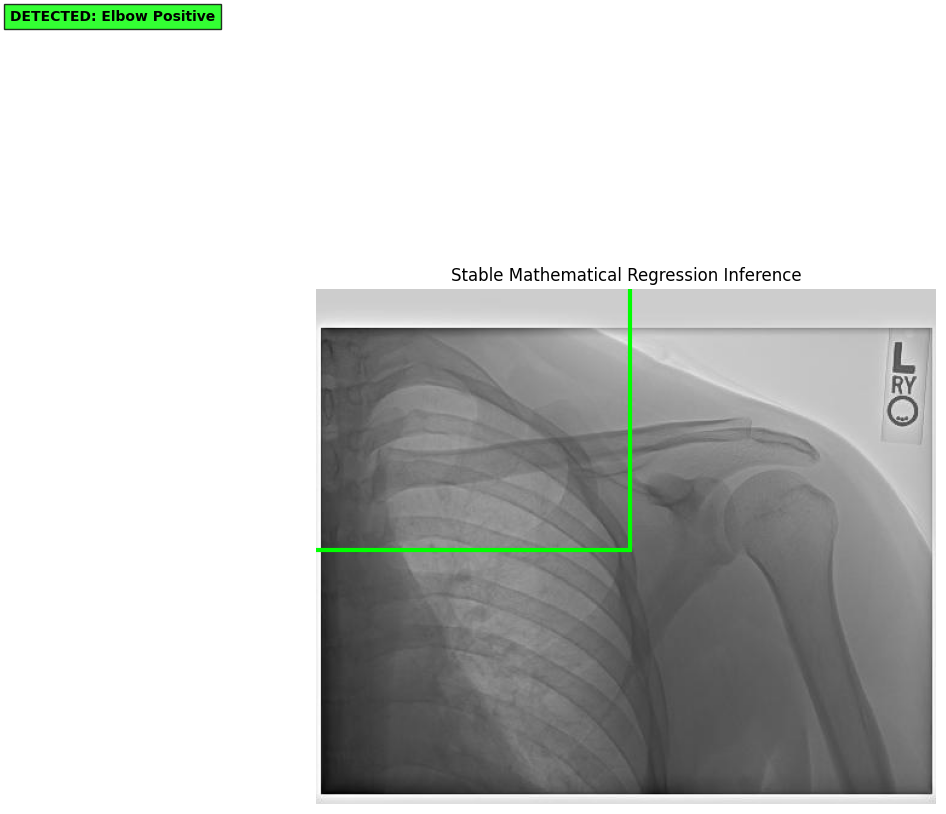

In [3]:
# =====================================================================
# 6. INFERENCE & EXPONENTIAL DECODING VISUALIZATION
# =====================================================================
model.eval()

# ASSIGN THIS to your specific test X-ray file name
test_img_path = "./dataset/test/images/image1_291_png.rf.c5a2f62a6316d1ebd9f91cb85ed65891.jpg" 

if not os.path.exists(test_img_path):
    print(f"Execution notice: Update the 'test_img_path' string variable to read a real X-ray file.")
else:
    orig_img = Image.open(test_img_path).convert("RGB")
    orig_w, orig_h = orig_img.size
    
    transform_eval = T.Compose([
        T.Resize((448, 448)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    tensor_img = transform_eval(orig_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_cls_logits, pred_box = model(tensor_img)
        pred_cls_logits = pred_cls_logits.cpu()
        pred_box = pred_box.cpu().squeeze(0).numpy()
        
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(orig_img, cmap='gray')
    
    # Extract prediction parameters
    x_c = pred_box[0]
    y_c = pred_box[1]
    
    # CRITICAL INVERSE MATH: Decode the width/height out of log space back to normal 0-1 scale using exponential
    w = torch.exp(torch.tensor(pred_box[2])).item()
    h = torch.exp(torch.tensor(pred_box[3])).item()
    
    # Hard-clip the resulting width/height safely at the very end *only* for graphic boundaries
    w = min(max(w, 0.01), 1.0)
    h = min(max(h, 0.01), 1.0)
    
    # Convert global ratios into direct image coordinates
    box_w = w * orig_w
    box_h = h * orig_h
    box_x = (x_c - w / 2) * orig_w
    box_y = (y_c - h / 2) * orig_h
    
    cls_id = torch.argmax(pred_cls_logits, dim=1).item()
    label = BONE_CLASSES[cls_id]
    
    rect = patches.Rectangle(
        (box_x, box_y), box_w, box_h, 
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)
    
    plt.text(
        box_x, box_y - 12, 
        f"DETECTED: {label}", 
        color='black', weight='bold', bbox=dict(facecolor='lime', alpha=0.8)
    )
    
    plt.axis('off')
    plt.title("Stable Mathematical Regression Inference", fontsize=12)
    plt.show()